# API Terrain Notebook
Drive the strm2stl pipeline via `TerrainSession`.

Steps:
1. **Start** — launch server
2. **Select** — pick region, review/edit settings
3. **Run** — fetch DEM → export OBJ → verify → slice to gcode
4. **Stop** — shut down server

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from terrain_session import TerrainSession

s = TerrainSession()
s.start()

Killing stale server on port 9000 (PID 10928, C:\Python311\python.exe)
Server running (PID 131236, python: c:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\.venv\Scripts\python.exe)


In [11]:
import ee
ee.Authenticate()

True

In [12]:
# List all regions (optional filter: filter_col="continent", filter_val="North America")
s.regions()

,name,continent,source,city,north,south,east,west
0,ADKs,None,coorlist,None,44.4167,43.9583,-73.6667,-74.2492
1,Aegean,Europe,None,None,43.0000,34.0000,30.9000,18.6000
2,Amazon,South America,None,None,15.0000,-19.0000,-45.0000,-85.0000
3,Appalachia,North America,None,None,50.0000,32.0000,-64.0000,-88.0000
4,Bahamas,North America,None,None,35.0000,10.0000,-60.0000,-88.0000
...,...,...,...,...,...,...,...,...
110,Yosemite,None,coorlist,None,37.8750,37.6250,-119.4167,-119.6667
111,YosemiteBig,None,coorlist,None,38.0000,37.6250,-119.2917,-119.6667
112,Zion National Park,None,coorlist,None,37.9167,37.0833,-112.5000,-113.3333
113,Zion National Park_2,None,coorlist,None,37.5000,37.0833,-112.6667,-113.1667


Showing 115 regions


,name,continent,source,city,north,south,east,west
0,ADKs,None,coorlist,None,44.4167,43.9583,-73.6667,-74.2492
1,Aegean,Europe,None,None,43.0000,34.0000,30.9000,18.6000
2,Amazon,South America,None,None,15.0000,-19.0000,-45.0000,-85.0000
3,Appalachia,North America,None,None,50.0000,32.0000,-64.0000,-88.0000
4,Bahamas,North America,None,None,35.0000,10.0000,-60.0000,-88.0000
...,...,...,...,...,...,...,...,...
110,Yosemite,None,coorlist,None,37.8750,37.6250,-119.4167,-119.6667
111,YosemiteBig,None,coorlist,None,38.0000,37.6250,-119.2917,-119.6667
112,Zion National Park,None,coorlist,None,37.9167,37.0833,-112.5000,-113.3333
113,Zion National Park_2,None,coorlist,None,37.5000,37.0833,-112.6667,-113.1667


In [13]:
# ← Change to the region you want, then edit settings below
s.select("Cartagena")

# ── Projection (applies to ALL layers: DEM, water mask, satellite, city) ────────
# projection: "none", "cosine", "mercator", "equal_area", "equidistant", "lambert", "sinusoidal"
s.settings["projection"]["projection"]         = "none"   # spatial warp applied to all fetched layers
s.settings["projection"]["maintain_dimensions"] = False   # True = pad to dim x dim; False = crop to valid data
s.settings["projection"]["clip_nans"]          = True     # strip all-NaN edge rows/cols — keeps result rectangular

# ── DEM fetch ──────────────────────────────────────────────────────────────────────
# DEM sources (no API key): "local", "h5_local"
# DEM sources (need OPENTOPO_API_KEY): "SRTMGL1", "SRTMGL3", "AW3D30", "COP30", "COP90", "SRTM15Plus"
s.settings["dem"]["dim"]                = 800      # output grid resolution (pixels per side)
s.settings["dem"]["depth_scale"]        = 0.5      # vertical scale applied to elevation values
s.settings["dem"]["water_scale"]        = 0.05     # vertical scale applied to water/ocean areas
s.settings["dem"]["subtract_water"]     = False    # depress water areas below terrain
s.settings["dem"]["dem_source"]         = "local"  # which DEM dataset to fetch from
s.settings["dem"]["show_sat"]           = False    # embed satellite overlay JPEG in DEM response (disables DEM cache)

# ── Water mask / water overlay ─────────────────────────────────────────────────────
# dataset controls both /api/terrain/water-mask AND the dem show_sat overlay
s.settings["water"]["dataset"]          = "esa"    # "esa" | "jrc"
s.settings["water"]["sat_scale"]        = 500      # m/px upper bound — auto-reduced for small regions (floor 30 m/px)

# ── Satellite imagery ──────────────────────────────────────────────────────────────────
s.settings["satellite"]["dim"]          = 800      # pixel resolution of returned JPEG (independent of dem.dim)

# ── Export ─────────────────────────────────────────────────────────────────────────
s.settings["export"]["model_height"]    = 30.0     # total model height in mm (terrain + base)
s.settings["export"]["base_height"]     = 10.0     # flat base thickness in mm
s.settings["export"]["exaggeration"]    = 1.0      # vertical exaggeration multiplier
s.settings["export"]["sea_level_cap"]   = False    # clamp ocean areas to z=0 (no deep-sea trenches)
s.settings["export"]["floor_val"]       = 0.0      # elevation floor — values below this are clamped
s.settings["export"]["engrave_label"]   = False    # engrave region name into base
s.settings["export"]["label_text"]      = ""       # override label text (empty = use region name)
s.settings["export"]["contours"]        = False    # add contour lines to mesh
s.settings["export"]["contour_interval"] = 100.0  # metres between contour lines
s.settings["export"]["contour_style"]   = "engraved"  # "engraved" | "embossed"
s.settings["export"]["puzzle_z"]        = None     # puzzle tab height in mm (None = auto)

# ── Puzzle split ───────────────────────────────────────────────────────────────────
s.settings["split"]["split_rows"]       = 2        # number of puzzle rows
s.settings["split"]["split_cols"]       = 2        # number of puzzle columns
s.settings["split"]["puzzle_m"]         = 50       # notch size in mm
s.settings["split"]["puzzle_base_n"]    = 10       # base tab depth in mm
s.settings["split"]["border_height"]    = 1.0      # raised lip height around each piece base (mm)
s.settings["split"]["border_offset"]    = 5.0      # inset distance of border from piece edge (mm)
s.settings["split"]["include_border"]   = True     # include raised lip on each puzzle piece

# ── Slicer ─────────────────────────────────────────────────────────────────────────
s.settings["slicer"]["slicer_config"]   = "maps_2025_part2.ini"  # PrusaSlicer .ini profile filename
s.settings["slicer"]["output_subdir"]   = "gcode"               # subfolder under output/ for gcode files

# ── City / OSM ───────────────────────────────────────────────────────────────────
s.settings["city"]["layers"]            = ["buildings", "roads", "waterways"]  # OSM feature types to fetch
s.settings["city"]["min_area"]          = 5.0      # m² — skip building footprints smaller than this
s.settings["city"]["simplify_tolerance"] = 0.5     # polygon simplification tolerance in metres
s.settings["city"]["building_scale"]    = 0.5      # mm per real metre for building heights in 3MF export
s.settings["city"]["road_depression_m"] = 0.0      # road surface depression depth (metres, 0 = flush)
s.settings["city"]["water_depression_m"] = -2.0    # waterway depression depth (metres, negative = inset)
s.settings["city"]["simplify_terrain"]  = True     # reduce terrain triangle count in city 3MF export

# ── Visualisation (local only — not sent to any endpoint) ─────────────────
s.settings["view"]["colormap"]          = "terrain" # matplotlib colormap name
s.settings["view"]["rescale_min"]       = None      # override elevation min for colour scaling (None = auto)
s.settings["view"]["rescale_max"]       = None      # override elevation max for colour scaling (None = auto)
s.settings["view"]["gridlines_show"]    = False     # overlay lat/lon gridlines on DEM image
s.settings["view"]["gridlines_count"]   = 5         # number of gridlines per axis

s.settings_table()

Region : Cartagena
BBox   : {'north': 10.4295, 'south': 10.3845, 'east': -75.5221, 'west': -75.5679}
── projection ──


,value
clip_nans,True
maintain_dimensions,False
projection,none


── dem ──


,value
dem_source,local
depth_scale,0.5
dim,800
show_sat,False
subtract_water,False
water_scale,0.05


── export ──


...

,value
dim,800


── city ──


,value
building_scale,0.5
layers,"['buildings', 'roads', 'waterways']"
min_area,5.0
road_depression_m,0.0
simplify_terrain,True
simplify_tolerance,0.5
water_depression_m,-2.0


── view ──


,value
colormap,terrain
elevation_curve,linear
elevation_curve_points,"[[0.0, 0.0], [0.4758213362864526, 0.4758213362..."
gridlines_count,5
gridlines_show,False
rescale_max,None
rescale_min,None


Fetching DEM…


min=-57.8 m  max=77.4 m  mean=2.2 m  shape=[800, 800]
shape=(800, 800)  min=-9.2  max=12.4


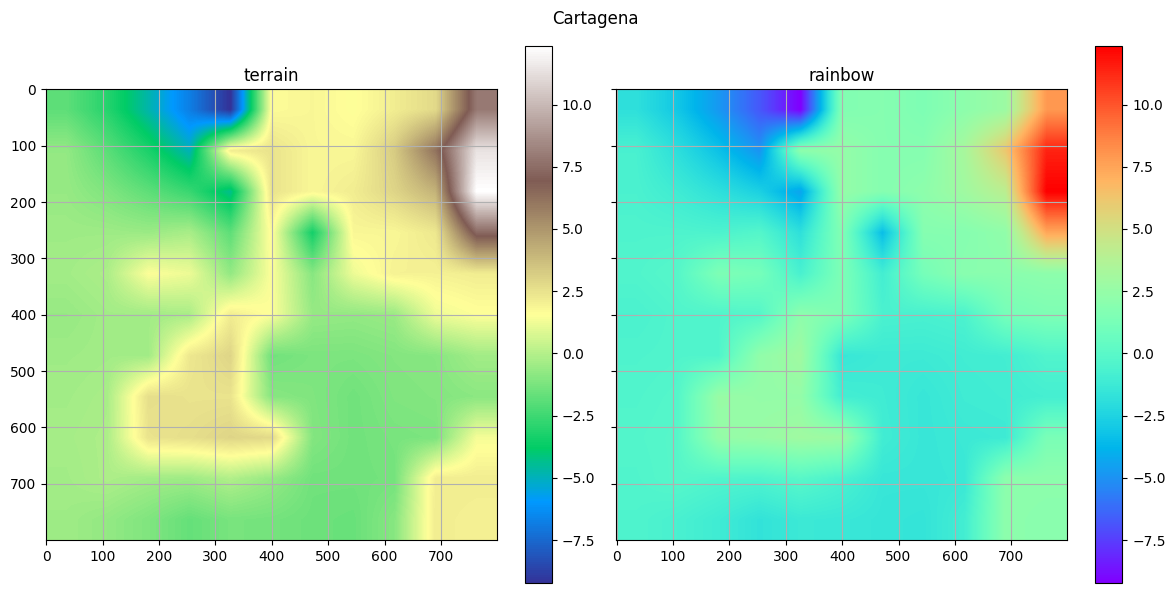

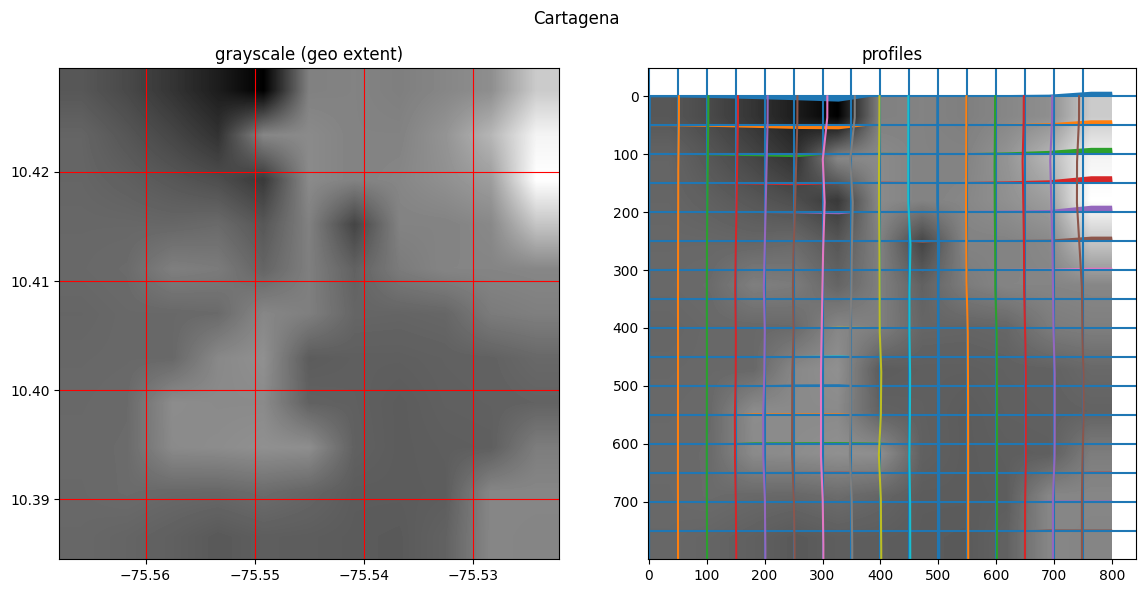

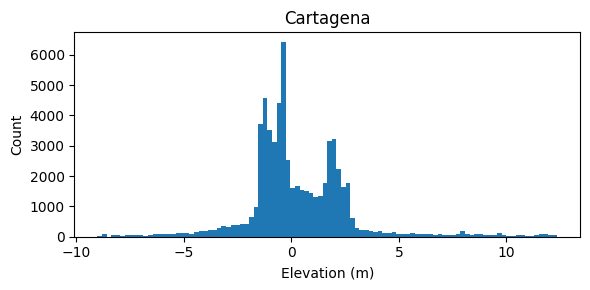

In [14]:
s.fetch_dem()
s.show_dem()

Fetching water mask…
Water coverage: 60.3%  |  grid: 511×502 px


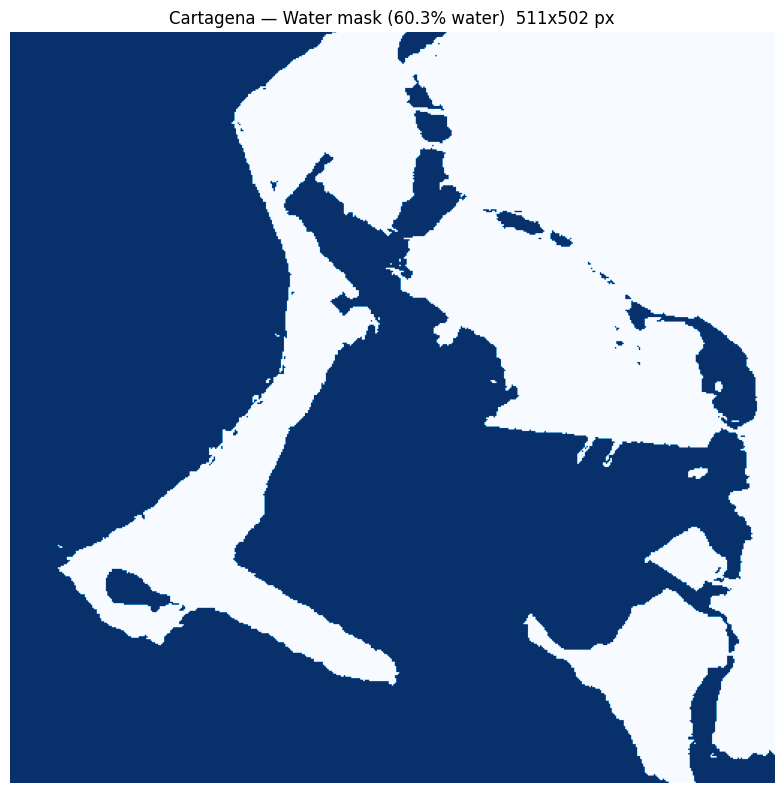

ESA land-cover: 511×502 px


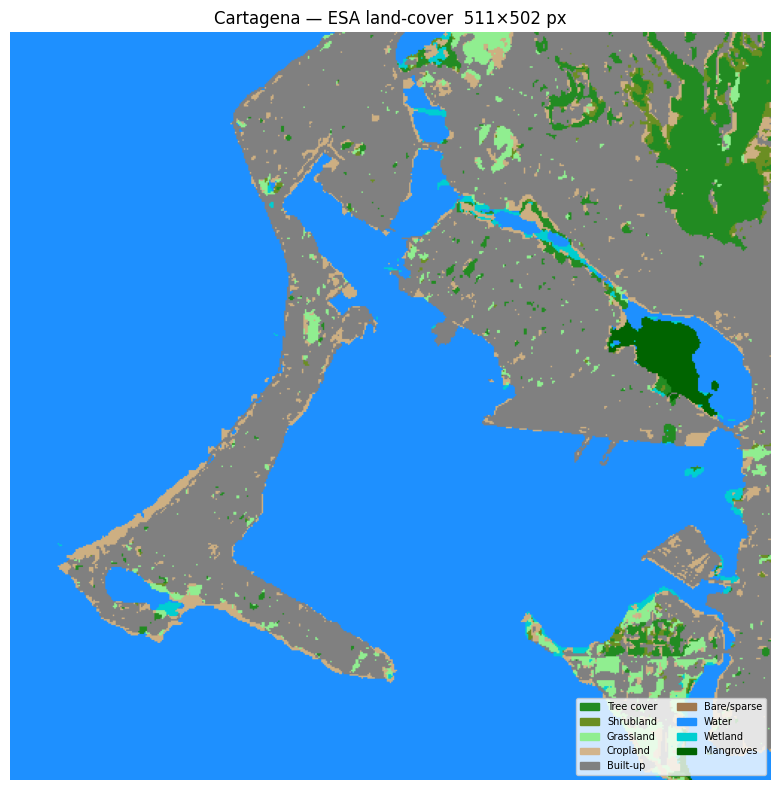

Fetching satellite image…
Satellite image received (218 KB base64)


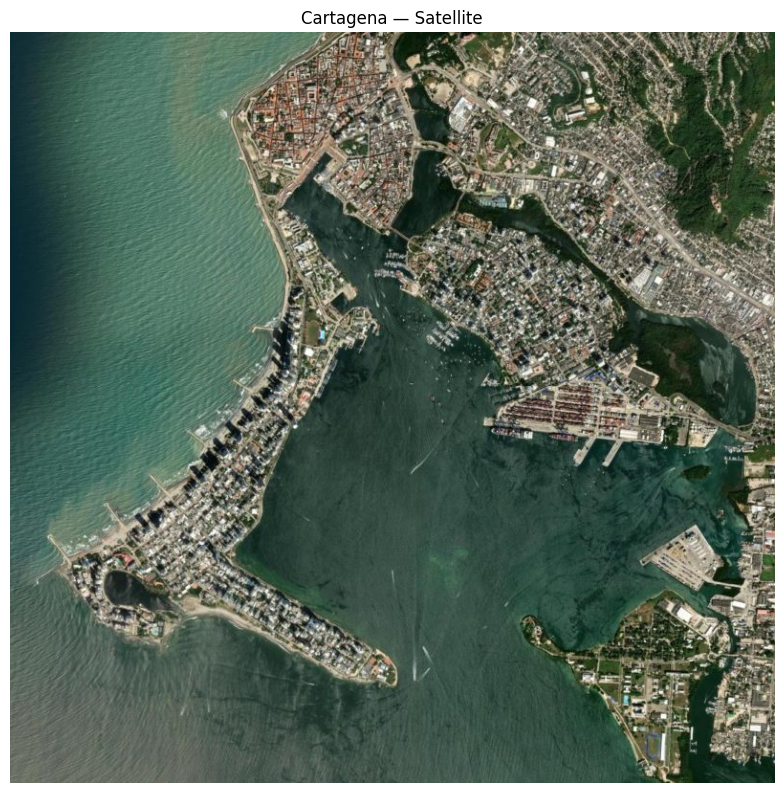

Fetching OSM city data…
Fetched 3015 buildings, 1805 roads, 47 waterways
City raster: 800×800 px, layers: buildings, roads, waterways, walls


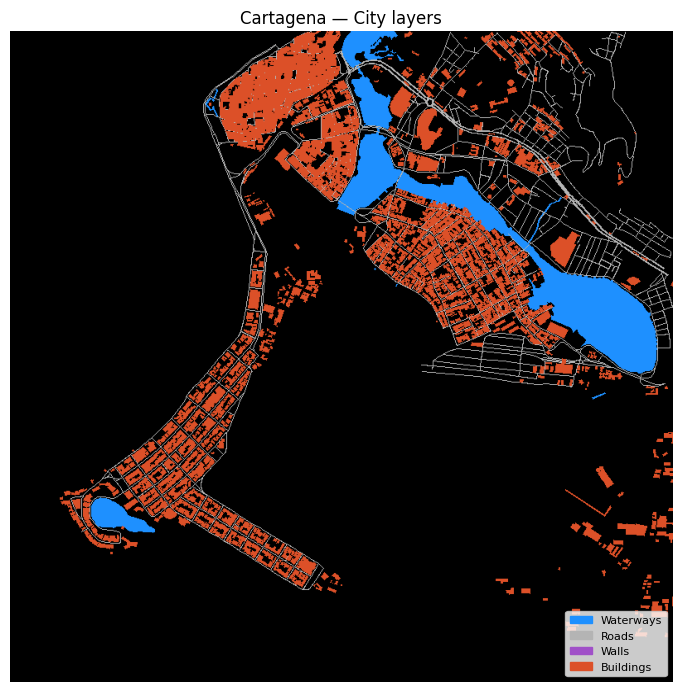

In [15]:
# Optional: fetch and display other layers
# NOTE: fetch_cities() requires a small bbox (<=10 km diagonal).
#       WestAmerica is continent-scale — select a city-scale region first.

# -- Water mask (binary 0/1) --
s.fetch_water_mask(max_display_dim=1000)
s.show_water_mask()

# -- ESA WorldCover land-cover classes (semantic colors) --
# free after fetch_water_mask() — no extra network call
s.fetch_esa_landcover(max_display_dim=1000)
s.show_esa_landcover()

# -- Satellite imagery (ESRI WMTS) --
s.fetch_satellite()
s.show_satellite()

# -- City / OSM features (city-scale regions only) --
s.fetch_cities()
s.composite_city_raster()
s.show_city()

  dem             800× 800 px  aspect=1.0000  Δ=1.7%  [reference geo]
  water_mask      511× 502 px  aspect=1.0179  Δ=0.0%  [OK]
  esa             511× 502 px  aspect=1.0179  Δ=0.0%  [OK]
  satellite       800× 786 px  aspect=1.0178  Δ=0.0%  [OK]
  city            800× 800 px  aspect=1.0000  Δ=1.7%  [OK]
  (expected)       geo W/H  aspect=1.0178  [geographic]


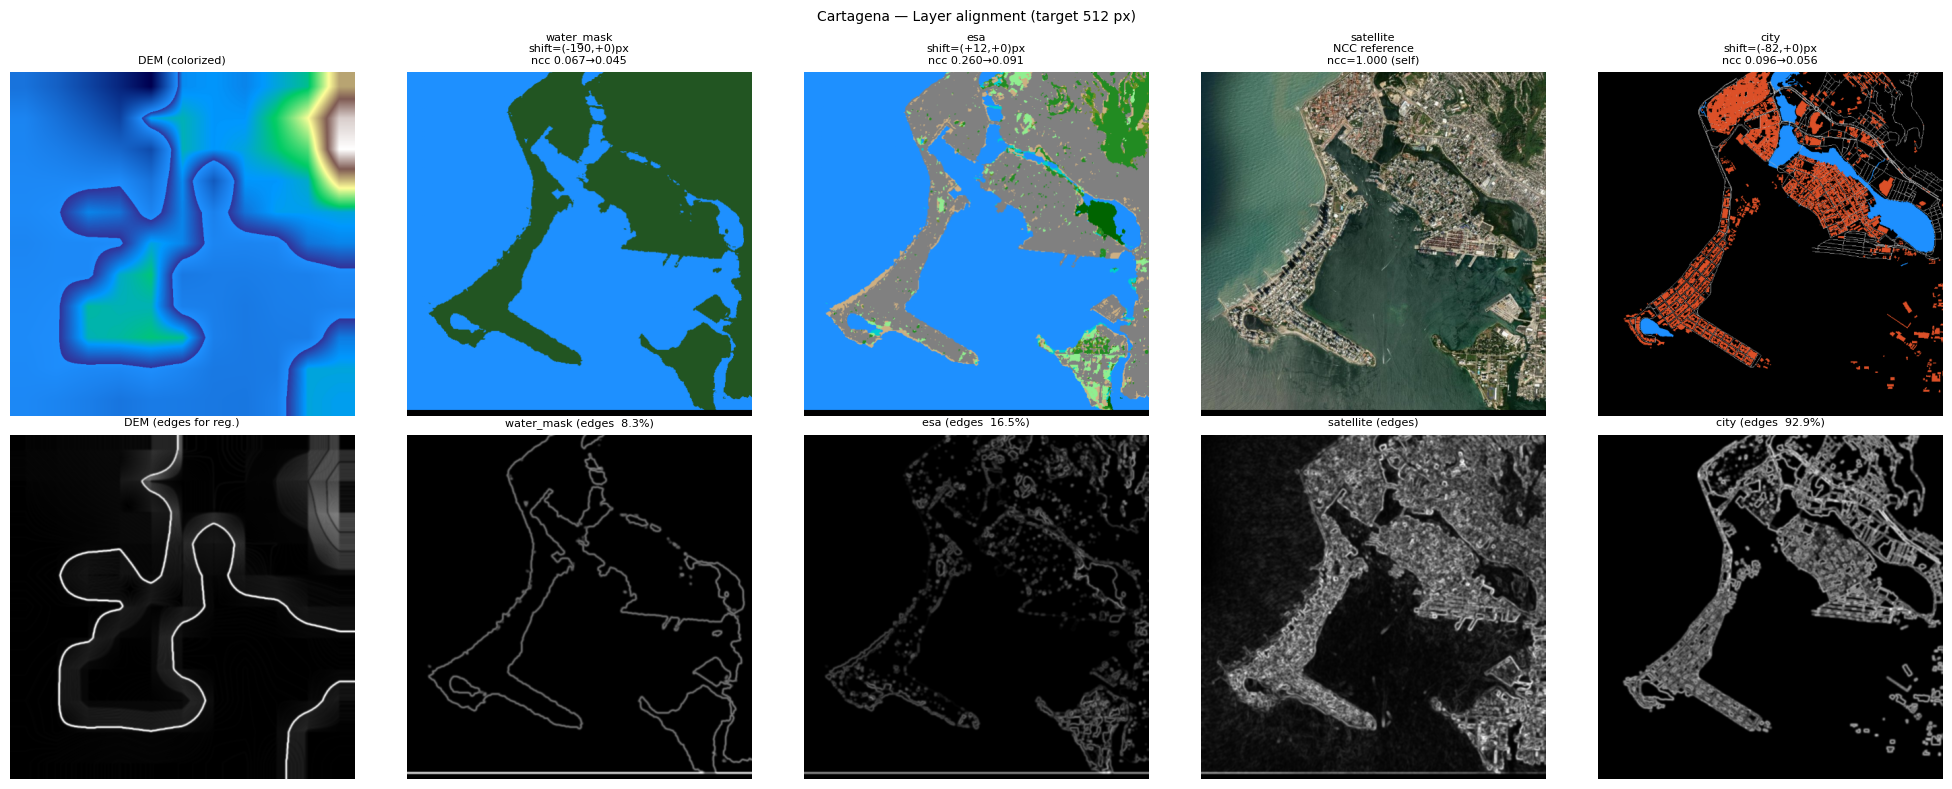


Alignment results  (shift via DEM edges, NCC vs satellite, min_shift=2.0px):
  layer           shift(dy,dx)    mag  applied  ncc_before  ncc_after    gain  note
  water_mask    (-190,  +0) px  190.0      yes      0.0675     0.0450  -0.0225
  esa           ( +12,  +0) px   12.0      yes      0.2604     0.0911  -0.1692
  satellite     (  +0,  +0) px    0.0       no      1.0000     1.0000  +0.0000  [NCC reference — not registered against itself]
  city          ( -82,  +0) px   82.0      yes      0.0964     0.0556  -0.0408


In [16]:
# ── Alignment check ───────────────────────────────────────────────────────────
# Requires fetch_dem() + at least one of fetch_water_mask / fetch_esa_landcover
# / fetch_satellite / fetch_cities to have been called first.
#
# How it works:
#   1. Builds a Sobel edge map from each layer's perceptual luminance
#   2. Runs phase_cross_correlation (DEM edges = reference) to detect any pixel offset
#   3. Rounds sub-pixel shift to nearest integer pixel
#   4. Skips applying the shift if its Euclidean magnitude < min_shift_px
#   5. Computes NCC (normalised cross-correlation) on the full RGB colorized images
#      before and after the shift, using satellite as ground-truth reference
#      (falls back to DEM colorization if satellite was not fetched).
#      ncc in [-1, 1]:  1.0 = identical structure, 0.0 = uncorrelated
#
# Results dict keys per layer:
#   shift_raw     — sub-pixel [dy, dx] from phase_cross_correlation
#   shift_int     — rounded integer [dy, dx]
#   magnitude     — Euclidean px distance of shift_int
#   applied       — False if magnitude < min_shift_px (negligible) or low_coverage=True
#   ncc_before    — RGB NCC vs satellite before any shift  [-1, 1]
#   ncc_after     — RGB NCC vs satellite after applying shift_int
#   ncc_gain      — ncc_after - ncc_before  (positive = shift improved alignment)
#   phasediff     — phase difference from phase_cross_correlation
#   edge_coverage — fraction of pixels with significant edges (< 0.02 = low signal)
#   low_coverage  — True if edge signal is too sparse to trust the detected shift
#   note          — explanation string when layer is skipped (e.g. NCC reference)

results = s.check_alignment(
    target_dim=512,      # rescale longer axis to this many px before correlating
    min_shift_px=2.0,    # shifts smaller than this are skipped (px in scaled space)
    upsample_factor=10,  # sub-pixel precision (10 → 0.1 px)
)

In [ ]:
s.export_obj()

Generating 2x2 puzzle split OBJ…
Saved: c:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\strm2stl\output\WestAmerica_puzzle_2x2.obj  (51469.2 KB)


In [ ]:
s.verify()

In [ ]:
s.slice()

In [ ]:
s.stop()